# Logistics & Route Analysis

Analyzing shipping mode performance, geographic route efficiency, cost per delivery lane, and delay hotspots.

**Hypotheses tested:** H1 (shipping mode delay), H2 (route variance)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

VISUALS_DIR = Path('../visuals')
VISUALS_DIR.mkdir(exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / f'{name}.png', dpi=150, bbox_inches='tight')


In [2]:
df = pd.read_csv('../data/supply_chain_cleaned.csv')
print(f'Shape: {df.shape}')
df.head(2)


Shape: (180519, 62)


,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_fname,customer_id,customer_lname,customer_segment,customer_state,customer_street,customer_zipcode,department_id,department_name,latitude,longitude,market,order_city,order_country,order_customer_id,order_date_dateorders,order_id,order_item_cardprod_id,order_item_discount,order_item_discount_rate,order_item_id,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total,order_profit_per_order,order_region,order_state,order_status,product_card_id,product_category_id,product_image,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode,order_year,order_month,order_day,order_dayofweek,order_quarter,order_hour,is_weekend,shipping_year,shipping_month,actual_shipping_delay,is_early_or_ontime,order_to_shipping_hours,order_season
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,Cally,20755,Holloway,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,2018,1,31,2,1,22,0,2018,2,-1.00,1,72.00,Winter
1,TRANSFER,5,4,-79.70,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,Irene,19492,Luna,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-79.70,South Asia,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,2018,1,13,5,1,12,1,2018,1,1.00,0,120.00,Winter


=== Shipping Mode Performance ===


,orders,on_time_pct,avg_delay_days,avg_sales,avg_profit
shipping_mode,,,,,
Second Class,35216,20.27,1.59,202.90,32.77
First Class,27814,0.00,1.00,204.01,33.32
Same Day,9737,52.17,0.48,199.50,31.60
Standard Class,107752,60.23,0.10,204.38,32.86


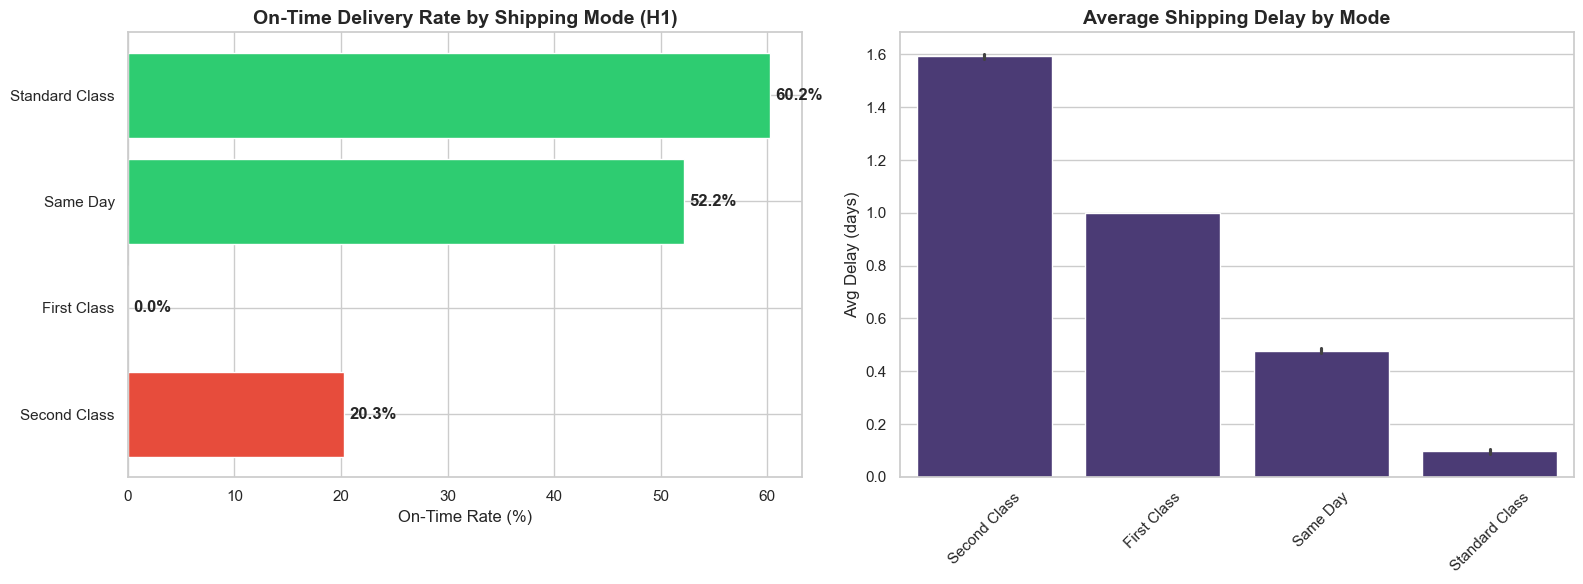

In [3]:
# Shipping Mode Performance (H1)
mode_agg = df.groupby('shipping_mode').agg(
    orders=('is_early_or_ontime', 'size'),
    on_time_rate=('is_early_or_ontime', 'mean'),
    avg_delay_days=('actual_shipping_delay', 'mean'),
    median_delay=('actual_shipping_delay', 'median'),
    avg_sales=('sales', 'mean'),
    avg_profit=('order_profit_per_order', 'mean')
).sort_values('avg_delay_days', ascending=False)
mode_agg['on_time_pct'] = mode_agg['on_time_rate'] * 100

print('=== Shipping Mode Performance ===')
display(mode_agg[['orders', 'on_time_pct', 'avg_delay_days', 'avg_sales', 'avg_profit']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#e74c3c' if v < 0.5 else '#2ecc71' for v in mode_agg['on_time_rate']]
axes[0].barh(mode_agg.index, mode_agg['on_time_pct'], color=colors)
axes[0].set_title('On-Time Delivery Rate by Shipping Mode (H1)')
axes[0].set_xlabel('On-Time Rate (%)')
for i, v in enumerate(mode_agg['on_time_pct']):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

sns.barplot(data=df, x='shipping_mode', y='actual_shipping_delay', order=mode_agg.index, ax=axes[1])
axes[1].set_title('Average Shipping Delay by Mode')
axes[1].set_xlabel('')
axes[1].set_ylabel('Avg Delay (days)')
axes[1].tick_params(axis='x', rotation=45)

save_fig('09_shipping_mode_performance')
plt.show()


=== Route Performance by Market x Region ===


,market,order_region,orders,on_time_rate,avg_delay,total_sales,total_profit,on_time_pct
12,Pacific Asia,Central Asia,553,0.43,0.62,"109,839.93","18,076.90",42.86
0,Africa,Central Africa,1677,0.39,0.62,"327,263.02","52,385.48",39.30
15,Pacific Asia,South Asia,7731,0.41,0.58,"1,553,680.92","247,696.63",41.50
8,Europe,Western Europe,27109,0.41,0.57,"5,894,380.77","931,512.04",41.48
20,USCA,South of USA,4045,0.42,0.57,"785,783.95","131,631.71",41.90
19,USCA,East of USA,6915,0.42,0.56,"1,371,111.99","229,283.00",42.02
1,Africa,East Africa,1852,0.43,0.56,"376,234.90","62,570.61",42.55
5,Europe,Eastern Europe,3920,0.43,0.56,"774,266.57","123,755.06",42.55
21,USCA,US Center,5887,0.43,0.56,"1,151,355.77","189,464.11",42.87
17,Pacific Asia,West Asia,6009,0.43,0.56,"1,174,671.78","187,018.90",42.50


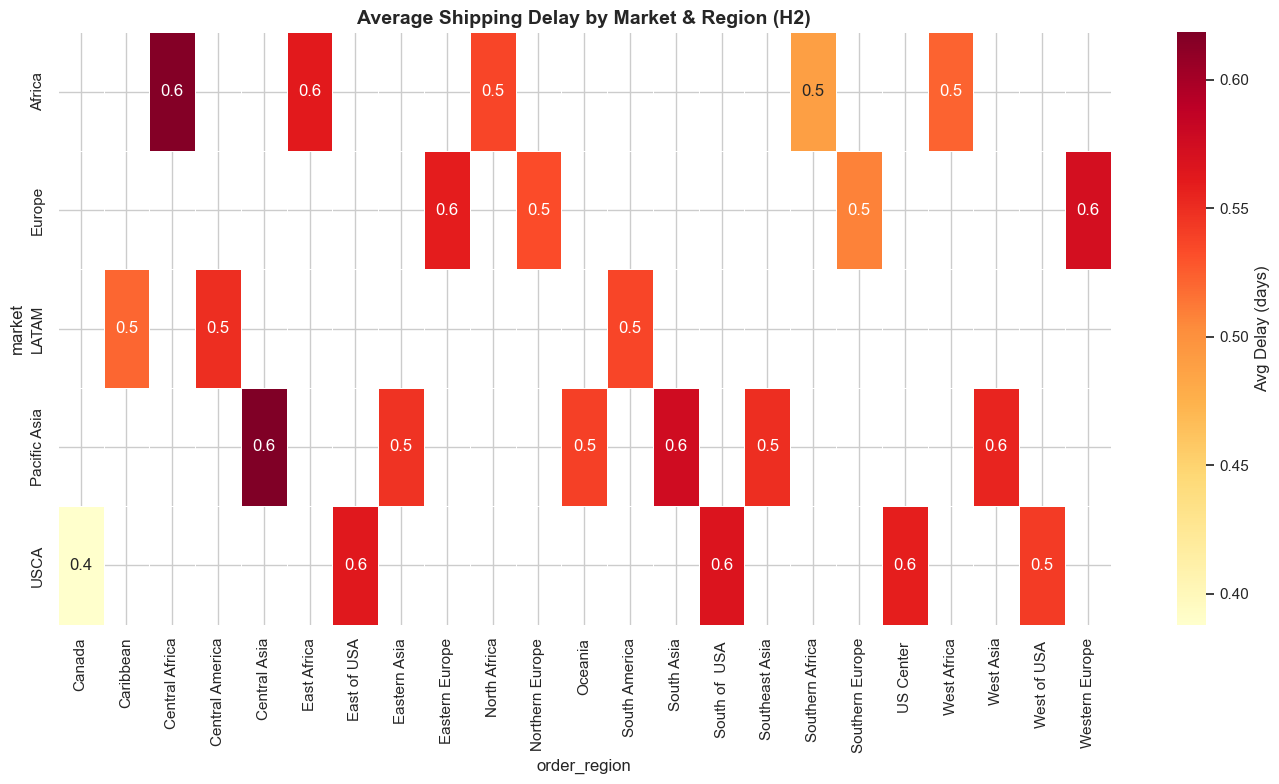

In [4]:
# Route Performance by Market & Region
route_agg = df.groupby(['market', 'order_region']).agg(
    orders=('is_early_or_ontime', 'size'),
    on_time_rate=('is_early_or_ontime', 'mean'),
    avg_delay=('actual_shipping_delay', 'mean'),
    total_sales=('sales', 'sum'),
    total_profit=('order_profit_per_order', 'sum')
).reset_index()
route_agg['on_time_pct'] = route_agg['on_time_rate'] * 100

print('=== Route Performance by Market x Region ===')
display(route_agg.sort_values('avg_delay', ascending=False).head(10))

fig, ax = plt.subplots(figsize=(14, 8))
pivot = route_agg.pivot_table(index='market', columns='order_region', values='avg_delay', aggfunc='mean')
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f', linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Delay (days)'})
ax.set_title('Average Shipping Delay by Market & Region (H2)')
save_fig('10_route_delay_heatmap')
plt.show()


Top 10 Most Delay-Prone Routes:


,route,orders,on_time_rate,avg_delay,avg_profit
8470,Cormeilles-en-Parisis -> New Brunswick,4,0.00,2.50,71.64
3064,Basildon -> Sugar Land,1,0.00,2.50,151.50
21027,Manzanillo -> La Habra,5,0.00,2.50,34.94
21025,Manzanillo -> Highland,3,0.00,2.50,51.99
34906,Teresina -> Chula Vista,4,0.00,2.50,-20.73
12697,Groningen -> Bakersfield,2,0.00,2.50,-2.02
14872,Ilopango -> Hollywood,1,0.00,2.50,5.97
3043,Basel -> Baytown,1,0.00,2.50,124.60
12698,Groningen -> Brooklyn,1,0.00,2.50,3.75
17862,Las Cruces -> Greensboro,3,0.00,2.50,42.25


/var/folders/5f/v7pqtktn107_c707d8vd5jc00000gn/T/ipykernel_18773/2564047464.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_delayed, y='route', x='avg_delay', palette='Reds_r', ax=ax)


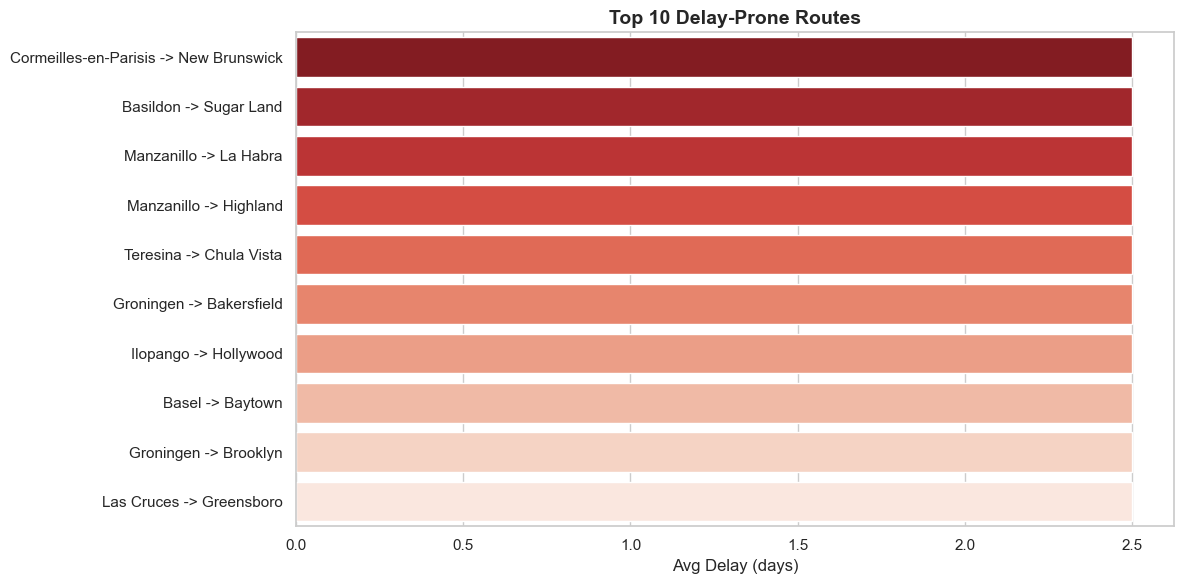

Top 10 Most Reliable Routes (by on-time rate):


,route,orders,on_time_rate,avg_delay,avg_profit
12205,Glasgow -> Caguas,68,0.71,-0.11,37.50
21085,Maracaibo -> Caguas,69,0.70,-0.12,45.02
21716,Medellín -> Caguas,75,0.69,-0.05,27.43
17014,Krefeld -> Caguas,51,0.69,-0.13,40.76
30545,San Martín -> Caguas,70,0.67,-0.03,33.32
22688,Milwaukee -> Caguas,54,0.67,-0.25,34.43
19420,Los Mochis -> Caguas,60,0.67,-0.07,33.10
8735,Culiacán -> Caguas,74,0.66,-0.15,27.40
9884,Dortmund -> Caguas,66,0.65,-0.01,32.24
22356,Mexico City -> Los Angeles,53,0.64,-0.11,35.18


In [5]:
# Top Origin-Destination Route Pairs
route_pairs = df.groupby(['order_city', 'customer_city']).agg(
    orders=('is_early_or_ontime', 'size'),
    on_time_rate=('is_early_or_ontime', 'mean'),
    avg_delay=('actual_shipping_delay', 'mean'),
    avg_profit=('order_profit_per_order', 'mean')
).reset_index()
route_pairs['route'] = route_pairs['order_city'] + ' -> ' + route_pairs['customer_city']

print('Top 10 Most Delay-Prone Routes:')
top_delayed = route_pairs.sort_values('avg_delay', ascending=False).head(10)
display(top_delayed[['route', 'orders', 'on_time_rate', 'avg_delay', 'avg_profit']].round(3))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_delayed, y='route', x='avg_delay', palette='Reds_r', ax=ax)
ax.set_title('Top 10 Delay-Prone Routes')
ax.set_xlabel('Avg Delay (days)')
ax.set_ylabel('')
save_fig('11_delayed_routes')
plt.show()

print('Top 10 Most Reliable Routes (by on-time rate):')
top_reliable = route_pairs[route_pairs['orders'] >= 50].sort_values('on_time_rate', ascending=False).head(10)
display(top_reliable[['route', 'orders', 'on_time_rate', 'avg_delay', 'avg_profit']].round(3))


In [6]:
# Customer Geographic Distribution
geo = df[['latitude', 'longitude', 'customer_city', 'customer_country',
          'is_early_or_ontime', 'actual_shipping_delay', 'shipping_mode']].copy()
geo['delay_category'] = geo['is_early_or_ontime'].map({1: 'On-Time', 0: 'Late'})
geo['delay_magnitude'] = geo['actual_shipping_delay'].abs() + 0.5

fig = px.scatter_map(
    geo.sample(min(5000, len(geo)), random_state=42),
    lat='latitude', lon='longitude',
    color='delay_category',
    size='delay_magnitude',
    hover_name='customer_city',
    hover_data={'customer_country': True, 'shipping_mode': True, 'actual_shipping_delay': True},
    color_discrete_map={'On-Time': '#2ecc71', 'Late': '#e74c3c'},
    zoom=1, height=600,
    title='Global Delivery Performance by Customer Location'
)
fig.update_layout(mapbox_style='carto-positron')
fig.write_html(str(VISUALS_DIR / 'delivery_map.html'))
print('Interactive map saved to visuals/delivery_map.html')
fig.show()


Interactive map saved to visuals/delivery_map.html


=== Late Delivery Rate by Region ===


,orders,late_rate,avg_delay,total_sales
order_region,,,,
Central Africa,1677,60.70,0.62,"327,263.02"
Western Europe,27109,58.52,0.57,"5,894,380.77"
South Asia,7731,58.50,0.58,"1,553,680.92"
South of USA,4045,58.10,0.57,"785,783.95"
Southeast Asia,9539,57.98,0.55,"1,932,495.57"
East of USA,6915,57.98,0.56,"1,371,111.99"
West Asia,6009,57.50,0.56,"1,174,671.78"
East Africa,1852,57.45,0.56,"376,234.90"
Eastern Europe,3920,57.45,0.56,"774,266.57"


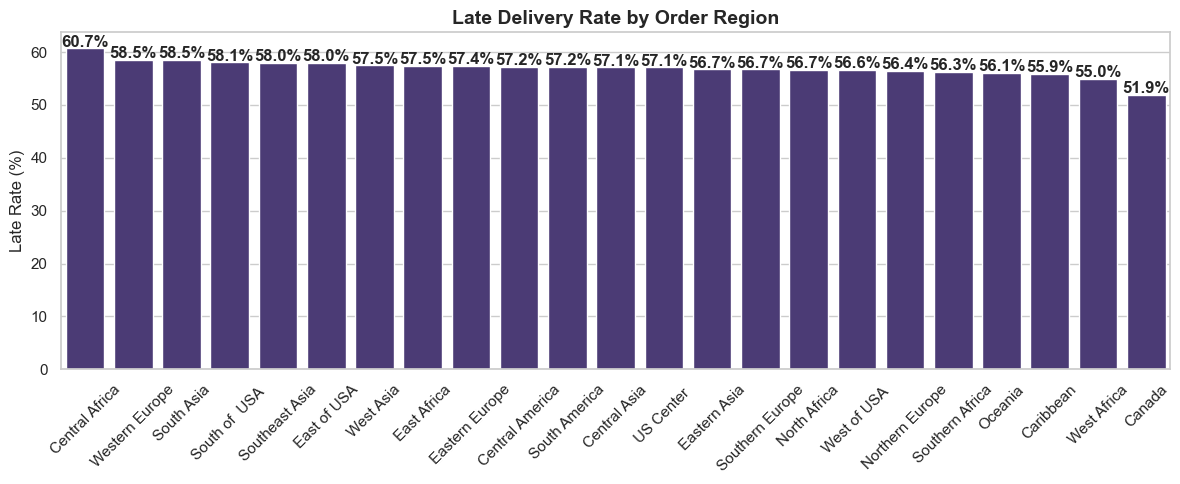

=== Regional Summary ===
Avg late rate: 57.0%
Worst region: Central Africa (60.7%)
Best region: Canada (51.9%)


In [7]:
# Regional Late Delivery Hotspots
region_stats = df.groupby('order_region').agg(
    orders=('is_early_or_ontime', 'size'),
    late_rate=('is_early_or_ontime', lambda s: (1 - s.mean()) * 100),
    avg_delay=('actual_shipping_delay', 'mean'),
    total_sales=('sales', 'sum')
).sort_values('late_rate', ascending=False)

print('=== Late Delivery Rate by Region ===')
display(region_stats.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=region_stats.index, y=region_stats['late_rate'], ax=ax)
ax.set_title('Late Delivery Rate by Order Region')
ax.set_ylabel('Late Rate (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(region_stats['late_rate']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
save_fig('12_regional_late_rate')
plt.show()

print('=== Regional Summary ===')
print(f'Avg late rate: {region_stats["late_rate"].mean():.1f}%')
print(f'Worst region: {region_stats.index[0]} ({region_stats.iloc[0]["late_rate"]:.1f}%)')
print(f'Best region: {region_stats.index[-1]} ({region_stats.iloc[-1]["late_rate"]:.1f}%)')


=== Cost & Profitability by Shipping Mode ===


,orders,avg_discount,avg_profit,avg_sales,profit_margin
shipping_mode,,,,,
First Class,27814,19.82,33.32,204.01,0.13
Same Day,9737,19.63,31.60,199.50,0.12
Second Class,35216,19.89,32.77,202.90,0.12
Standard Class,107752,19.85,32.86,204.38,0.12


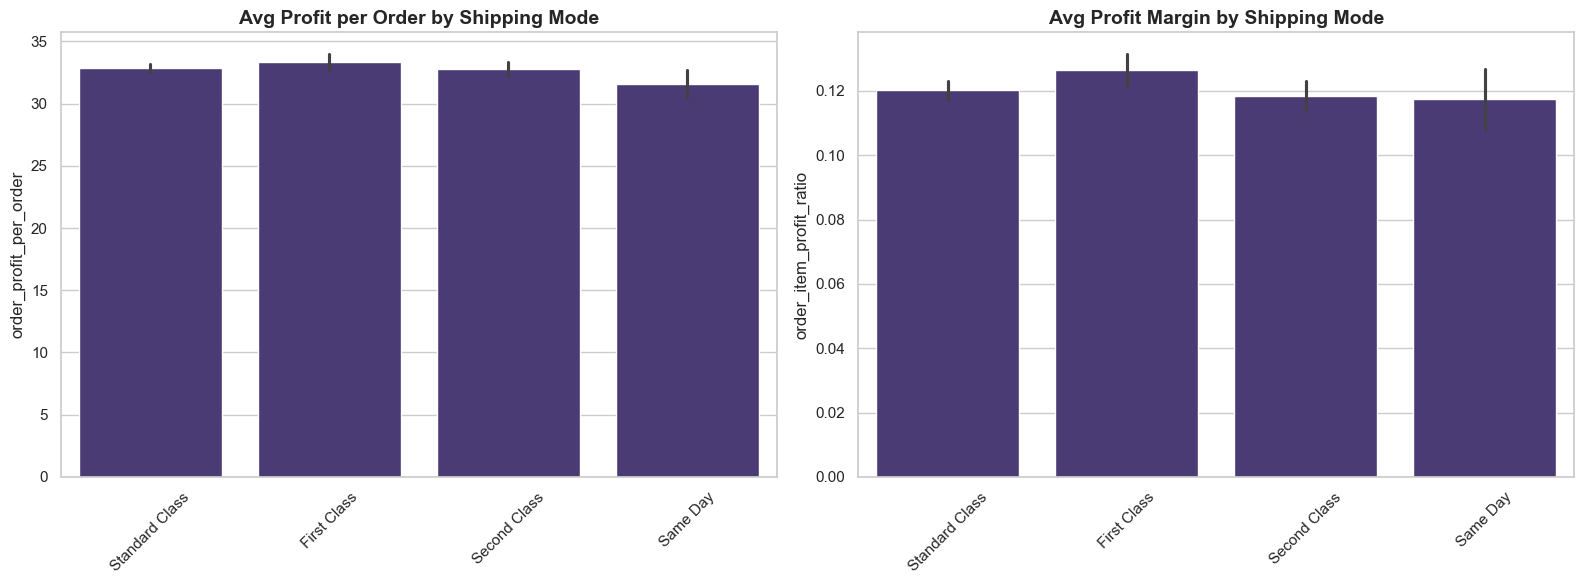

In [8]:
# Cost Analysis by Shipping Mode
cost_by_mode = df.groupby('shipping_mode').agg(
    orders=('order_item_quantity', 'size'),
    avg_discount=('order_item_discount', 'mean'),
    avg_profit=('order_profit_per_order', 'mean'),
    avg_sales=('sales', 'mean'),
    profit_margin=('order_item_profit_ratio', 'mean')
).round(2)

print('=== Cost & Profitability by Shipping Mode ===')
display(cost_by_mode)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=df, x='shipping_mode', y='order_profit_per_order', ax=axes[0])
axes[0].set_title('Avg Profit per Order by Shipping Mode')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='shipping_mode', y='order_item_profit_ratio', ax=axes[1])
axes[1].set_title('Avg Profit Margin by Shipping Mode')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

save_fig('13_cost_by_mode')
plt.show()


=== Expedited vs. Standard Shipping ===


,orders,on_time_pct,avg_delay,avg_discount,avg_sales
shipping_tier,,,,,
Expedited,37551,13.53,0.86,19.77,202.84
Standard,142968,50.39,0.47,19.86,204.02


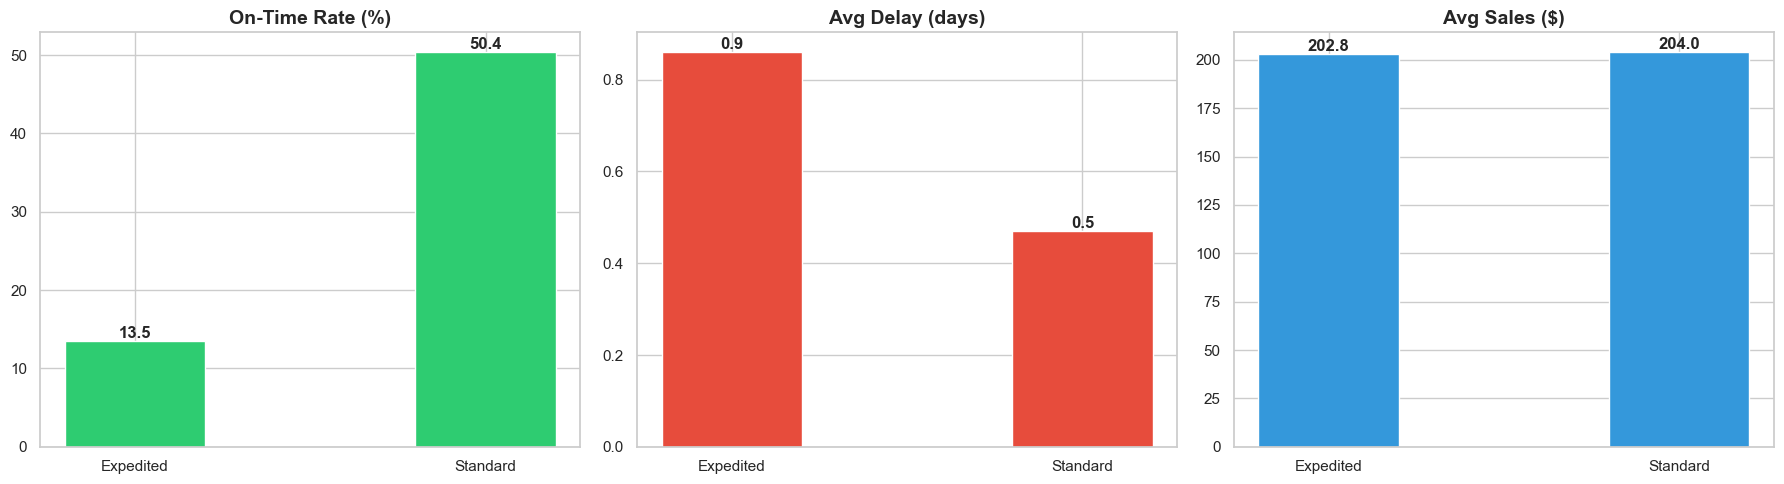

In [9]:
# Expedited vs Standard Shipping
expedited_modes = ['First Class', 'Same Day']
df['shipping_tier'] = df['shipping_mode'].apply(lambda x: 'Expedited' if x in expedited_modes else 'Standard')

tier_comp = df.groupby('shipping_tier').agg(
    orders=('is_early_or_ontime', 'size'),
    on_time_pct=('is_early_or_ontime', lambda s: s.mean() * 100),
    avg_delay=('actual_shipping_delay', 'mean'),
    avg_discount=('order_item_discount', 'mean'),
    avg_sales=('sales', 'mean')
).round(2)

print('=== Expedited vs. Standard Shipping ===')
display(tier_comp)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('on_time_pct', 'On-Time Rate (%)', '#2ecc71'),
           ('avg_delay', 'Avg Delay (days)', '#e74c3c'),
           ('avg_sales', 'Avg Sales ($)', '#3498db')]
for ax, (col, label, color) in zip(axes, metrics):
    ax.bar(tier_comp.index, tier_comp[col], color=color, width=0.4)
    ax.set_title(label)
    for i, v in enumerate(tier_comp[col]):
        ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')
save_fig('14_expedited_vs_standard')
plt.show()


In [10]:
print('=' * 60)
print('LOGISTICS & ROUTING KEY FINDINGS')
print('=' * 60)

print(f'Shipping modes analyzed: {df["shipping_mode"].nunique()}')
print(f'Markets covered: {df["market"].nunique()}')
print(f'Order regions: {df["order_region"].nunique()}')
print(f'Unique origin-destination routes: {route_pairs["route"].nunique()}')

best_mode = mode_agg['on_time_pct'].idxmax()
worst_mode = mode_agg['on_time_pct'].idxmin()
print(f'Best mode: {best_mode} ({mode_agg.loc[best_mode, "on_time_pct"]:.1f}%)')
print(f'Worst mode: {worst_mode} ({mode_agg.loc[worst_mode, "on_time_pct"]:.1f}%)')

exp_avg = tier_comp.loc['Expedited', 'avg_delay']
std_avg = tier_comp.loc['Standard', 'avg_delay']
print(f'Expedited avg delay: {exp_avg:.2f} days vs Standard: {std_avg:.2f} days')

print('Interactive map saved to visuals/delivery_map.html')
print('All static visuals saved to visuals/')


LOGISTICS & ROUTING KEY FINDINGS


Shipping modes analyzed: 4
Markets covered: 5
Order regions: 23
Unique origin-destination routes: 39107
Best mode: Standard Class (60.2%)
Worst mode: First Class (0.0%)
Expedited avg delay: 0.86 days vs Standard: 0.47 days
Interactive map saved to visuals/delivery_map.html
All static visuals saved to visuals/
